# Vendor Performance & Business Analytics

**Analyst:** Data Analytics Team  
**Database:** SQLite (`inventory.db`)  
**Dataset:** `vendor_sales_summary`

---

## Executive Summary

This notebook provides **actionable commercial insights** into vendor performance, pricing elasticity, procurement concentration, and inventory velocity using statistical modeling, hypothesis testing, and business intelligence techniques.

### Key Strategic Analyses

1. **Statistical Profiling & Data Quality Audit** - Distribution shape, outliers, and metric correlations
2. **Promotional Opportunity Identification** - Low-sales, high-margin brands suitable for targeted demand stimulation
3. **Vendor & Brand Sales Rankings** - Top revenue drivers across the supplier portfolio
4. **Procurement Concentration & Pareto Analysis** - Top-10 vendor spend share and supply-chain dependency
5. **Bulk Purchasing Volume Economics** - Unit cost compression across purchase order volume tiers
6. **Inventory Velocity & Capital Lock-Up** - Slow-moving stock and working capital exposure identification
7. **Profitability Benchmarking & Hypothesis Testing** - 95% confidence intervals and two-sample t-test comparing top vs. low performing vendors

---

## 📚 Table of Contents
1. [Import Libraries & Styling Configuration](#ImportingLibraries)
2. [Load Dataset & Environment Setup](#Dataset)
3. [Exploratory Data Analysis & Statistical Profiling](#ExploratoryDataAnalysis)
4. [Business Analysis & Strategic Insights](#DataAnalysis)


<a id='ImportingLibraries'></a>
## 📦 Import Libraries

**Core Libraries:**
- **pandas** - Data manipulation and analysis
- **numpy** - Numerical computing
- **matplotlib & seaborn** - Data visualization
- **scipy** - Statistical hypothesis testing
- **sqlite3** - Database connectivity

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Statistical analysis
import scipy.stats as stats
from scipy.stats import ttest_ind

# Database & filesystem
import sqlite3
from pathlib import Path

# Configuration & Aesthetics
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Professional styling defaults
sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#cbd5e1'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.titlesize'] = 13
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

# Ensure images directory exists (resolves from repo root or notebooks/)
IMG_DIR = Path('images')
if not IMG_DIR.exists() and Path('../images').exists():
    IMG_DIR = Path('../images')
IMG_DIR.mkdir(parents=True, exist_ok=True)


---

<a id='Dataset'></a>
## 📊 Load Dataset

### Data Source
- **Table:** `vendor_sales_summary`
- **Database:** `inventory.db` (SQLite)
- **Rows:** ~10,692 vendor-brand combinations

### Schema
Pre-aggregated vendor metrics including purchase/sales quantities, dollars, profit margins, and turnover rates.

In [2]:
# creating database connection
# Resolve DB path relative to this notebook's directory or repo root
DB_PATH = Path('notebooks/inventory.db') if Path('notebooks/inventory.db').exists() else Path('inventory.db')
conn = sqlite3.connect(DB_PATH)

# fetching vendor summary data
df = pd.read_sql_query("select * from vendor_sales_summary", conn)
df.head()


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [3]:
csv_out = Path('notebooks/vendor_sales_summary.csv') if Path('notebooks').exists() else Path('vendor_sales_summary.csv')
df.to_csv(csv_out, index=False)


---

<a id='ExploratoryDataAnalysis'></a>
# 🔍 Exploratory Data Analysis

## Objective
Understand data distributions, identify outliers, and validate data quality in the `vendor_sales_summary` table.

### Analysis Components
1. **Descriptive Statistics** - Central tendency and dispersion
2. **Distribution Analysis** - Histogram and KDE plots
3. **Outlier Detection** - Boxplot visualization
4. **Correlation Analysis** - Heatmap of numeric variables
5. **Categorical Analysis** - Top vendors and products

---

In [4]:
# Summary statistics for numerical columns
summary_stats = df.describe().T  
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269375,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246016,0.490000,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.360550,664.309212,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.710000,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.000000,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,42239.074419,167655.265984,0.000000,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,18793.783627,44952.773386,0.000000,289.710000,2857.800000,16059.562500,6.728193e+05


In [5]:
# Mode for each numerical column
mode_values = df.mode().iloc[0]
print("\nMode Values:\n\n", mode_values)



Mode Values:

 VendorNumber                            4425.0
VendorName               MARTIGNETTI COMPANIES
Brand                                      809
Description                   Southern Comfort
PurchasePrice                             6.53
ActualPrice                               9.99
Volume                                   750.0
TotalPurchaseQuantity                     12.0
TotalPurchaseDollars                     95.28
TotalSalesQuantity                        12.0
TotalSalesDollars                          0.0
TotalSalesPrice                            0.0
TotalExciseTax                             0.0
FreightCost                          144929.24
GrossProfit                                0.0
ProfitMargin                               0.0
StockTurnover                              1.0
SalesToPurchaseRatio                       0.0
Name: 0, dtype: object


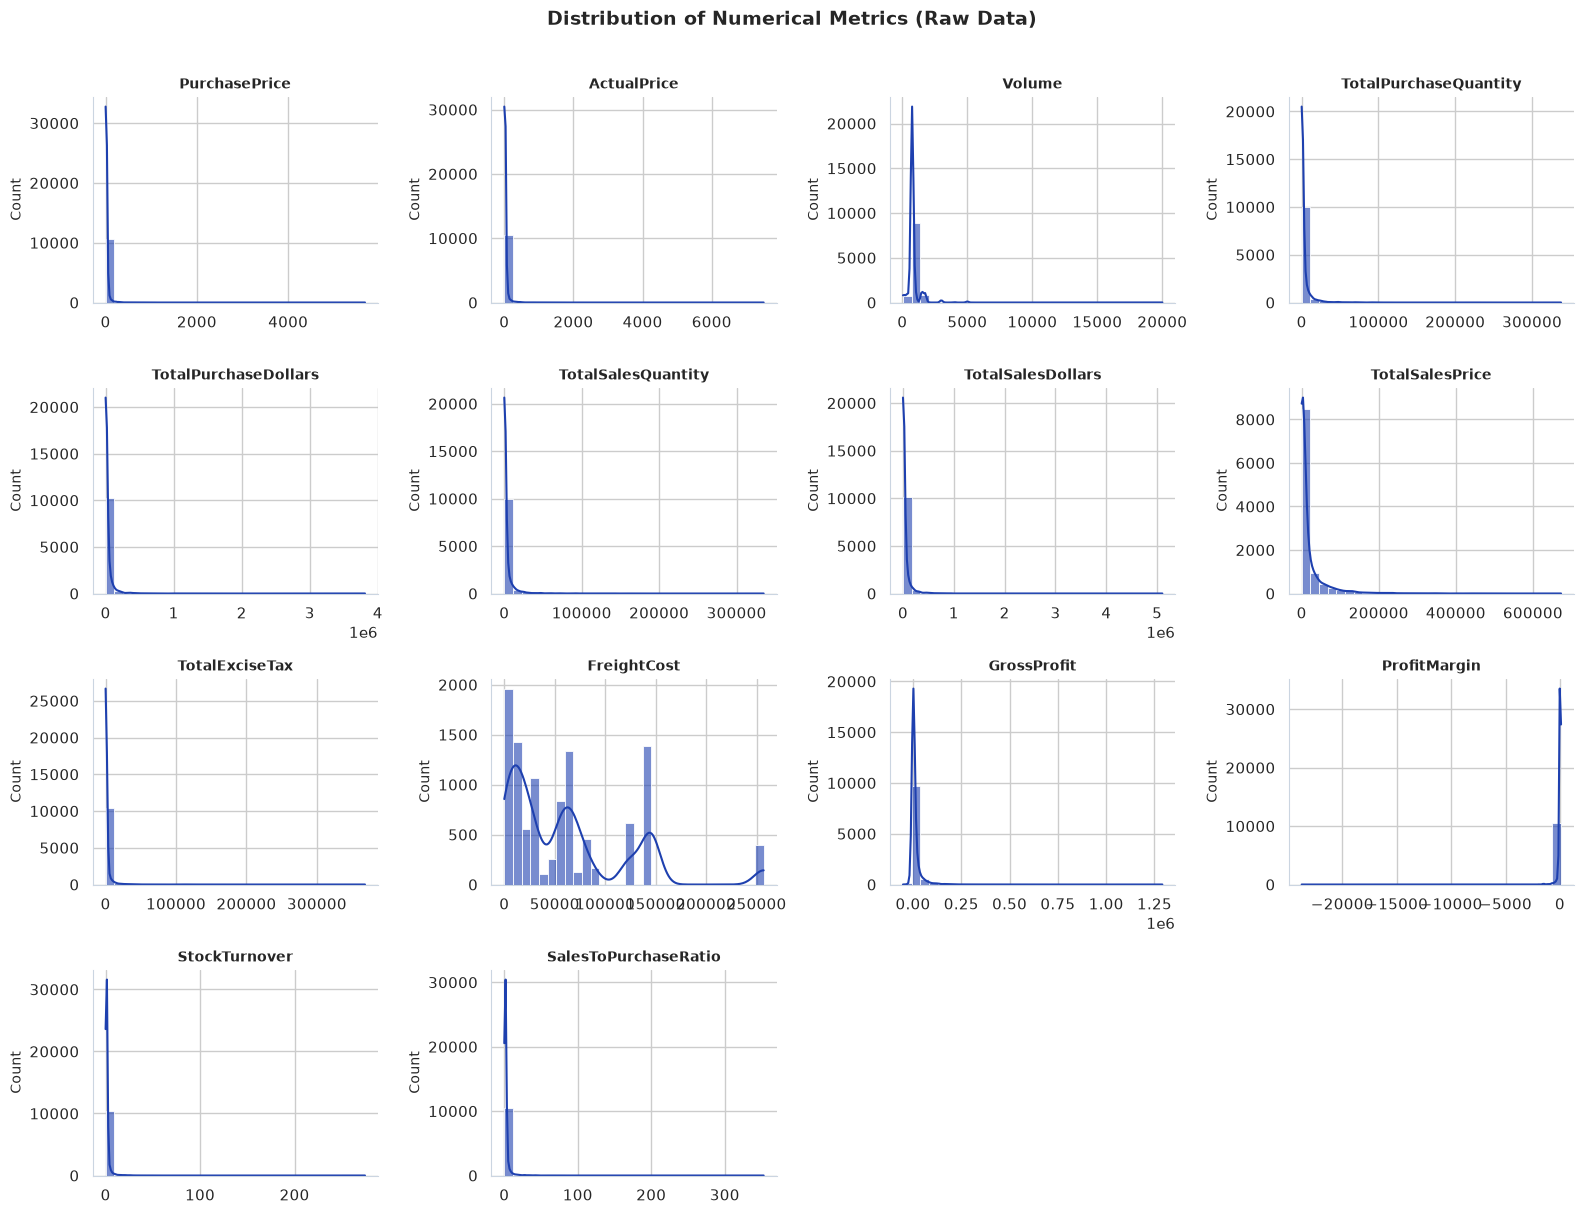

In [6]:
# Distribution Plots for Numerical Columns (Raw Data)
id_cols = ['VendorNumber', 'Brand']
numerical_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in id_cols]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color="#1e40af", edgecolor="white", alpha=0.6)
    axes[i].set_title(col, fontsize=10, fontweight="bold", pad=6)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    sns.despine(ax=axes[i])
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Distribution of Numerical Metrics (Raw Data)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_distributions_raw.png", dpi=300, bbox_inches="tight")
plt.show()


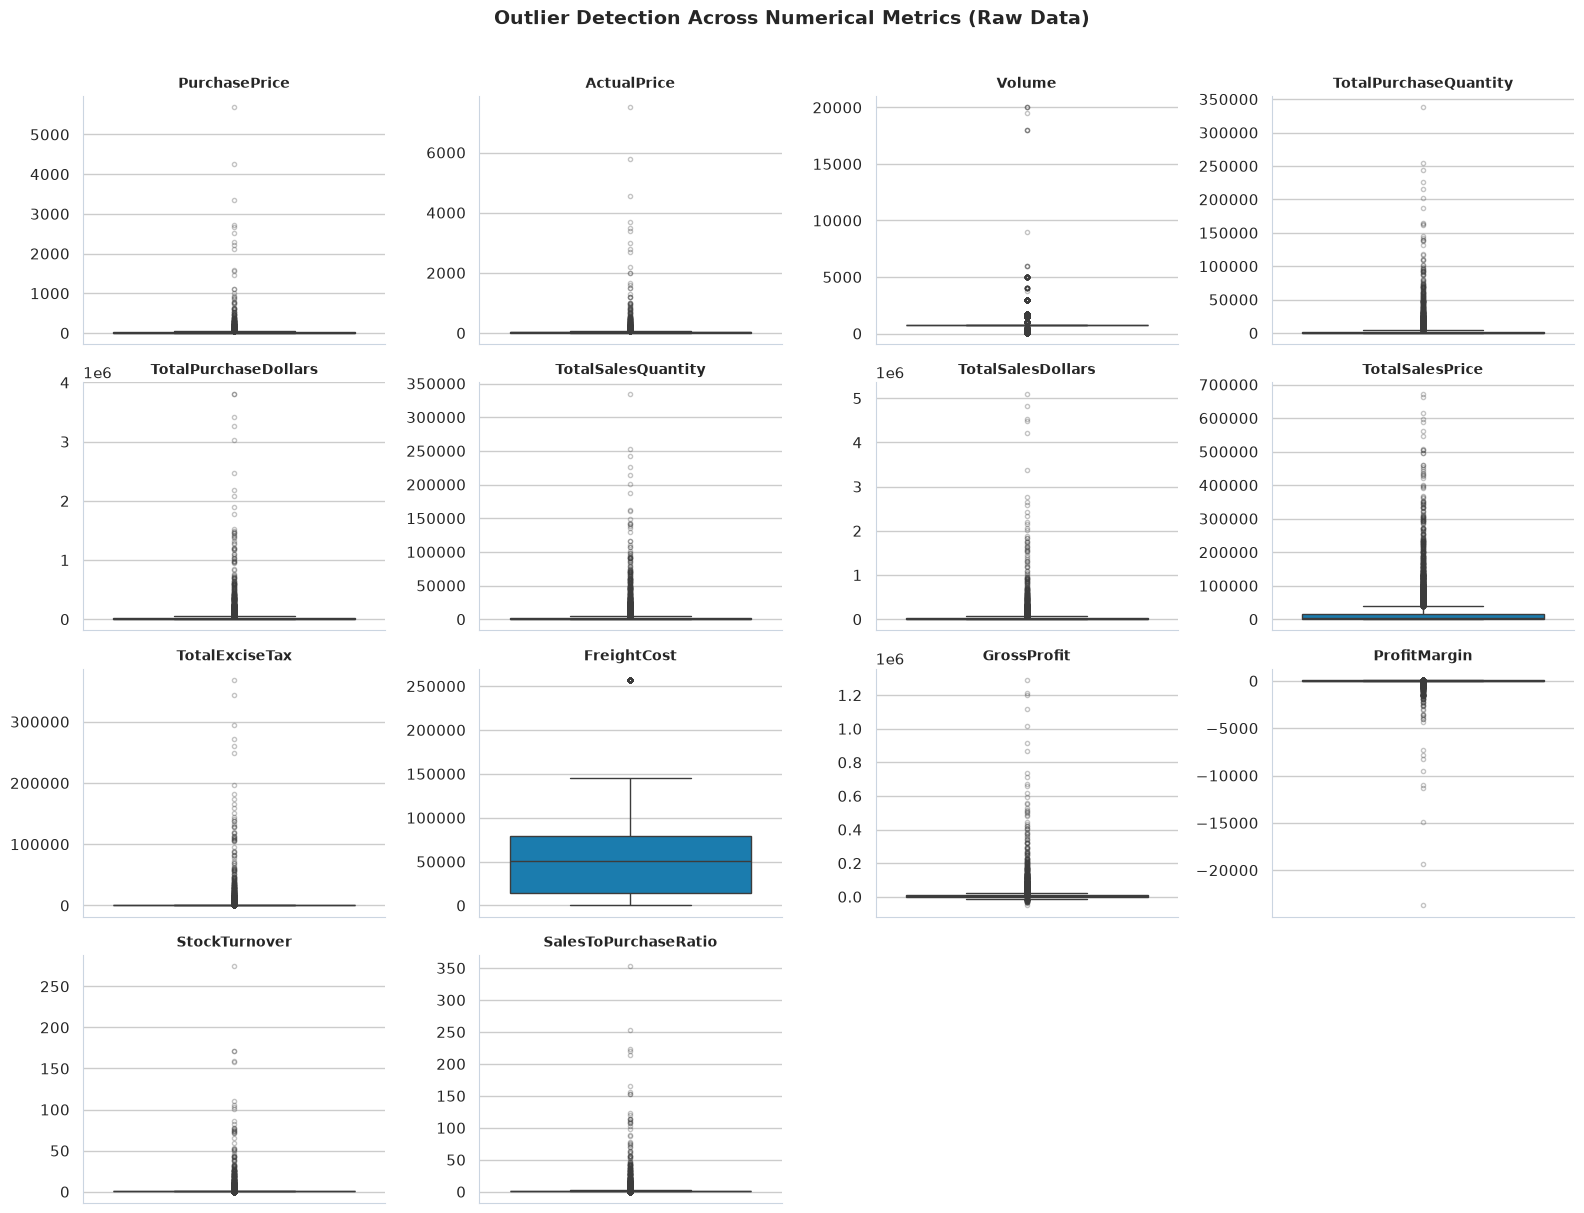

In [7]:
# Outlier Detection with Boxplots (Raw Data)
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#0284c7",
                flierprops=dict(marker='o', markersize=3, alpha=0.3, color='#94a3b8'))
    axes[i].set_title(col, fontsize=10, fontweight="bold", pad=6)
    axes[i].set_ylabel("")
    sns.despine(ax=axes[i])
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Outlier Detection Across Numerical Metrics (Raw Data)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_boxplots_raw.png", dpi=300, bbox_inches="tight")
plt.show()


### 📈 Key Statistical Insights

#### 🚨 Data Anomalies Identified

**Negative & Zero Values:**
- **Gross Profit:** Min = -$52,002.78 → Indicates loss-making transactions (selling below cost)
- **Profit Margin:** Min = -∞ → Cases where revenue equals zero or negative
- **Total Sales:** Min = 0 → Unsold inventory (purchased but never sold)

**High Variability (Outliers):**
- **Purchase/Actual Prices:** Max values ($5,681/$7,499) vs. Mean ($24/$36) suggest premium products
- **Freight Cost:** Range $0.09 - $257,032 indicates bulk shipments or logistics inefficiencies
- **Stock Turnover:** Range 0 - 274.5 reveals extreme inventory velocity differences
  - Values >1 indicate sales from older stock (inventory carried forward)

#### 💡 Business Implications
- Negative margins require pricing strategy review
- Zero-sales products tie up working capital
- High freight variability presents cost optimization opportunity

In [8]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query("""SELECT * 
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""",conn)

In [9]:
df.shape

(8564, 18)

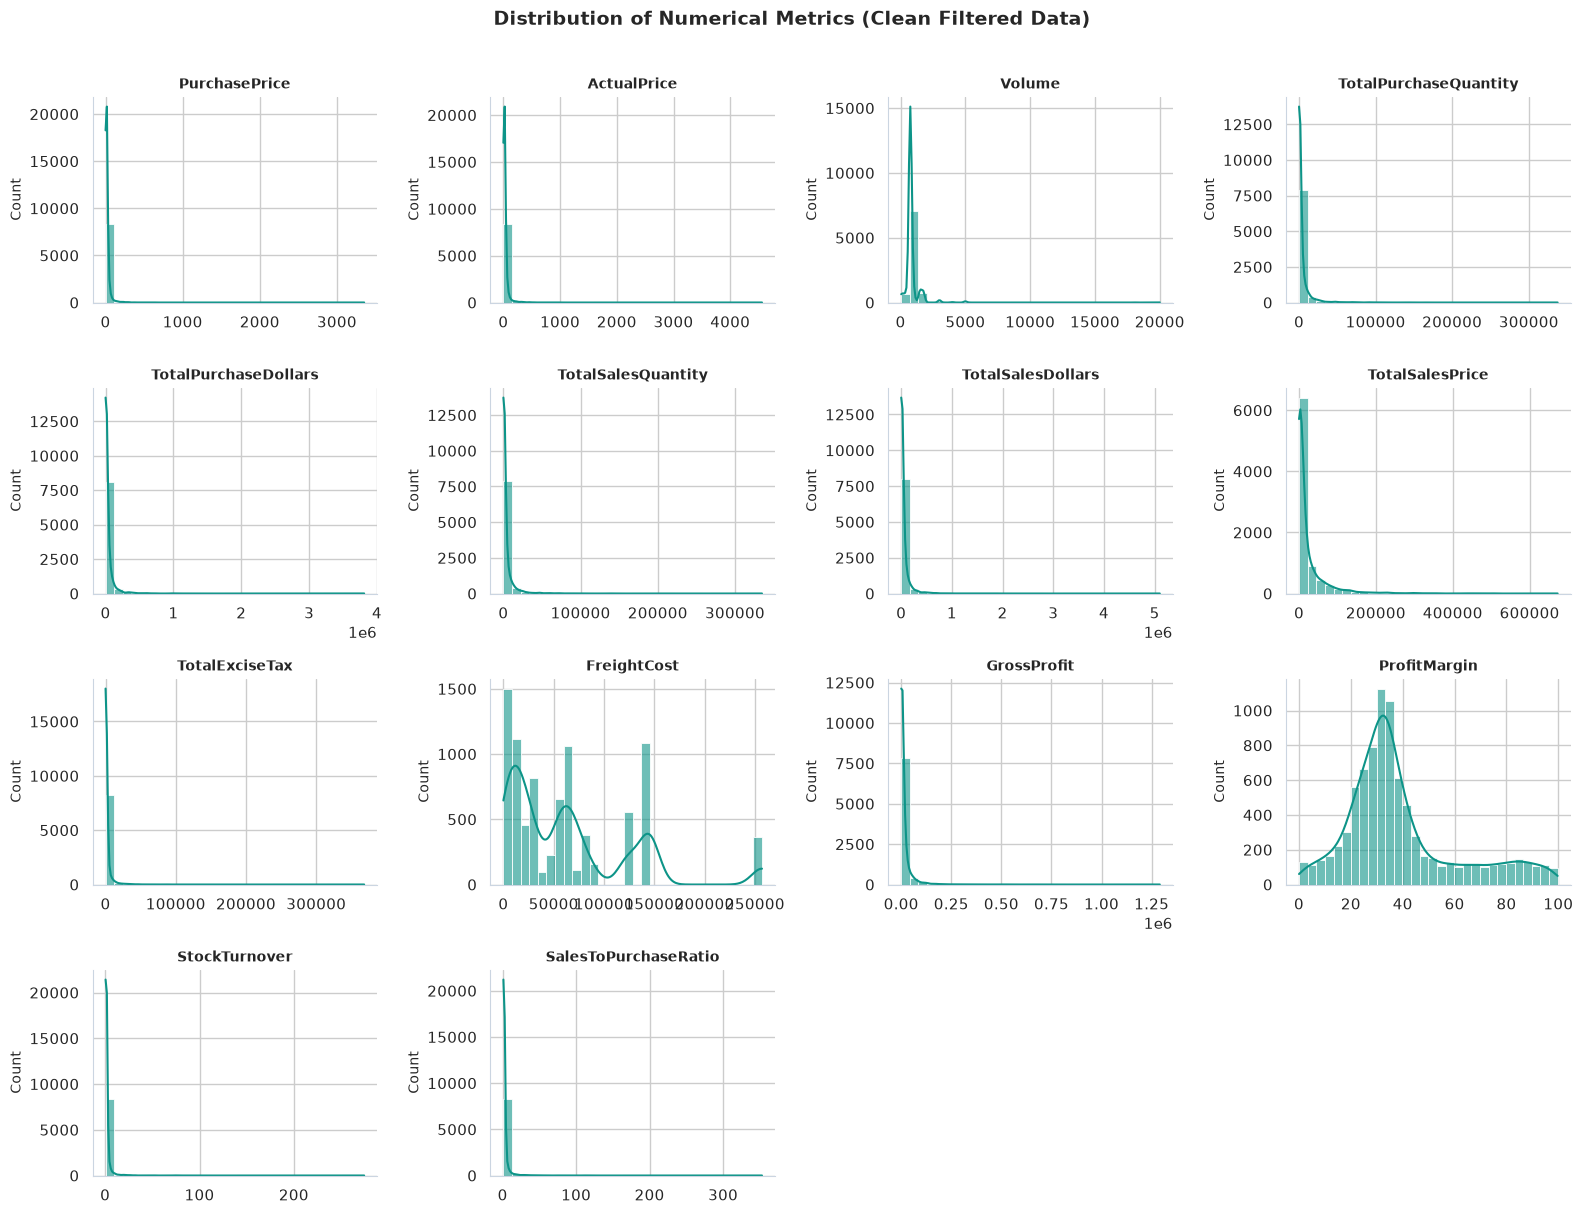

In [10]:
# Distribution Plots for Numerical Columns (Filtered Data)
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color="#0d9488", edgecolor="white", alpha=0.6)
    axes[i].set_title(col, fontsize=10, fontweight="bold", pad=6)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    sns.despine(ax=axes[i])
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Distribution of Numerical Metrics (Clean Filtered Data)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_distributions_filtered.png", dpi=300, bbox_inches="tight")
plt.show()


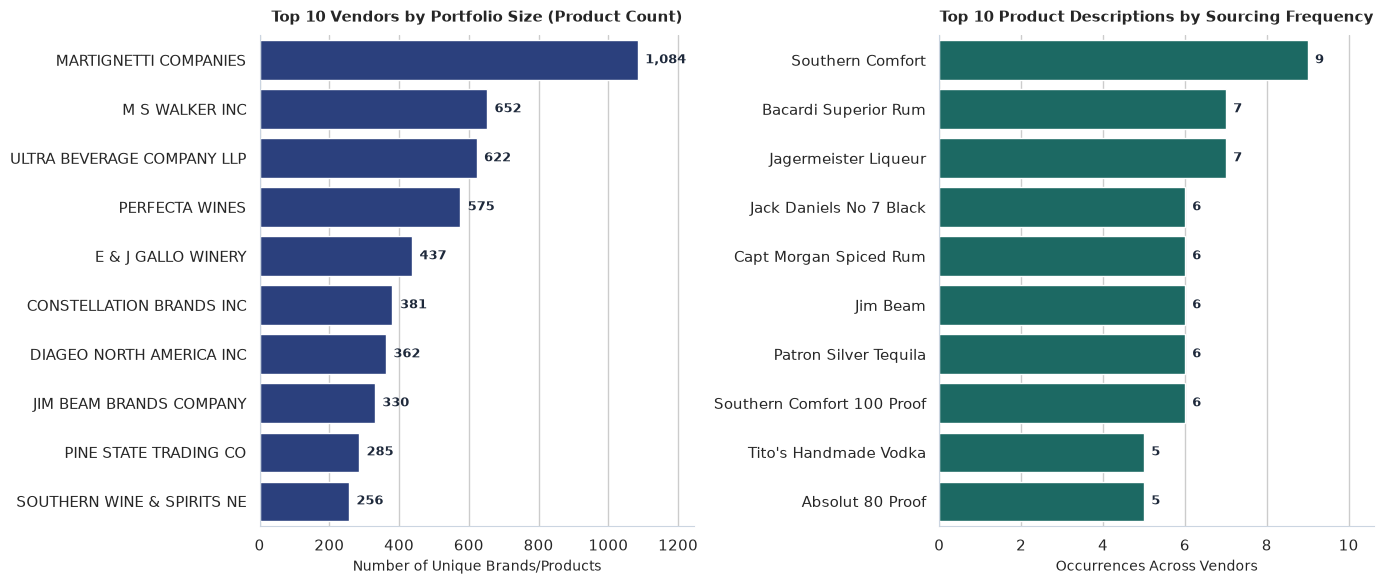

In [11]:
# Count Plots for Categorical Columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

top_vend_counts = df["VendorName"].value_counts().head(10)
sns.barplot(y=top_vend_counts.index, x=top_vend_counts.values, ax=ax1, color="#1e3a8a")
ax1.set_title("Top 10 Vendors by Portfolio Size (Product Count)", fontsize=11, fontweight="bold", pad=10)
ax1.set_xlabel("Number of Unique Brands/Products")
ax1.set_ylabel("")
ax1.set_xlim(0, max(top_vend_counts.values) * 1.15)
for bar in ax1.patches:
    ax1.text(bar.get_width() + (max(top_vend_counts.values) * 0.02),
             bar.get_y() + bar.get_height() / 2,
             f"{int(bar.get_width()):,}",
             ha='left', va='center', fontsize=9, fontweight='bold', color='#1e293b')
sns.despine(ax=ax1)

top_desc_counts = df["Description"].value_counts().head(10)
sns.barplot(y=top_desc_counts.index, x=top_desc_counts.values, ax=ax2, color="#0f766e")
ax2.set_title("Top 10 Product Descriptions by Sourcing Frequency", fontsize=11, fontweight="bold", pad=10)
ax2.set_xlabel("Occurrences Across Vendors")
ax2.set_ylabel("")
ax2.set_xlim(0, max(top_desc_counts.values) * 1.18)
for bar in ax2.patches:
    ax2.text(bar.get_width() + (max(top_desc_counts.values) * 0.02),
             bar.get_y() + bar.get_height() / 2,
             f"{int(bar.get_width()):,}",
             ha='left', va='center', fontsize=9, fontweight='bold', color='#1e293b')
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig(IMG_DIR / "eda_categorical_counts.png", dpi=300, bbox_inches="tight")
plt.show()


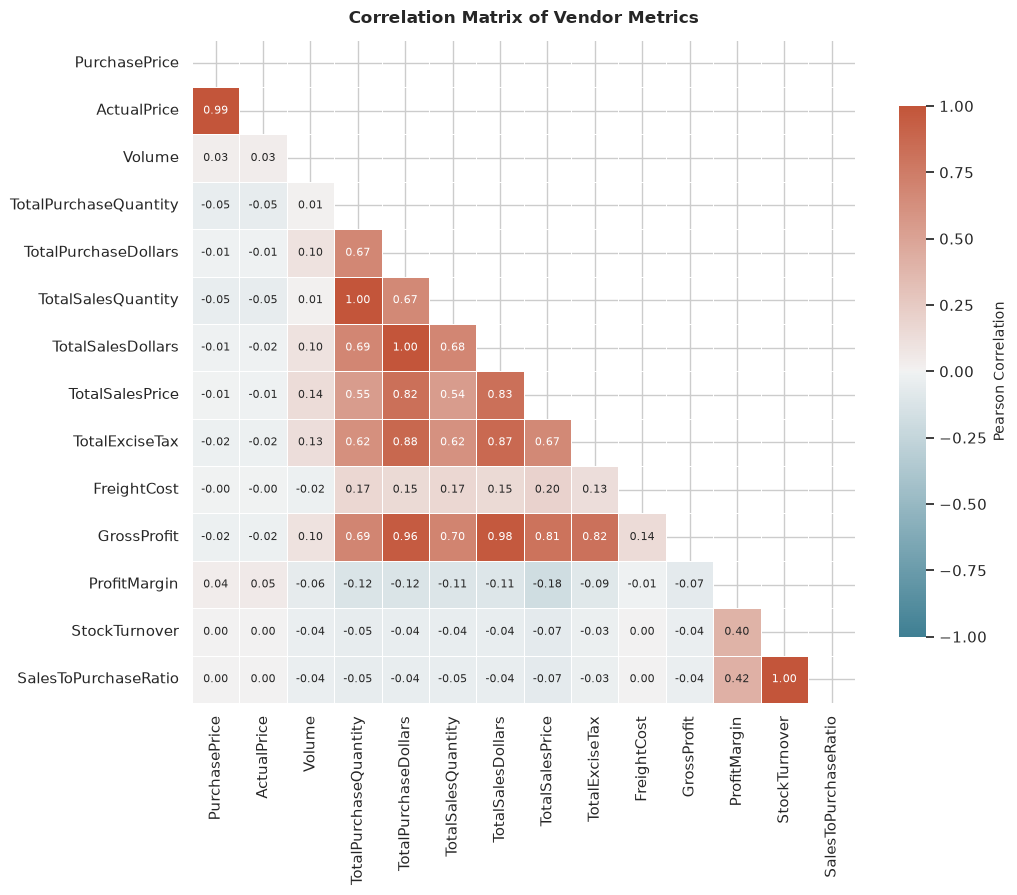

In [12]:
# Correlation Heatmap
plt.figure(figsize=(11, 9))
corr = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, annot=True, fmt=".2f",
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
            annot_kws={"size": 8})
plt.title("Correlation Matrix of Vendor Metrics", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


### 🔗 Correlation Matrix Insights

#### Key Relationships

| Relationship | Correlation | Business Interpretation |
|--------------|-------------|-------------------------|
| **PurchasePrice ↔ TotalSales** | -0.012 (weak) | Price variations don't significantly drive sales volume |
| **Purchase Qty ↔ Sales Qty** | +0.999 (strong) | Excellent inventory turnover efficiency |
| **Profit Margin ↔ Sales Price** | -0.179 (negative) | Higher prices compress margins (competitive pressure) |
| **Stock Turnover ↔ Gross Profit** | -0.038 (weak) | Fast turnover ≠ higher profitability |

#### Strategic Implications

✅ **Inventory Management:** Near-perfect purchase-to-sales alignment (r=0.999)  
⚠️ **Pricing Strategy:** Price increases may not improve margins due to competitive dynamics  
💡 **Profitability Focus:** Turnover velocity alone doesn't guarantee profitability  

---

<a id='DataAnalysis'></a>
# 💼 Business Analysis & Insights

## Strategic Questions Addressed

This section answers critical business questions using statistical methods and visualization:

1. **Promotional Opportunities** - Which low-sales, high-margin products warrant targeted promotions?
2. **Top Performers** - Which vendors and brands drive the most sales?
3. **Procurement Concentration** - How dependent are we on top vendors?
4. **Bulk Pricing Efficiency** - Do volume discounts materialize as expected?
5. **Inventory Risk** - Which vendors have slow-moving stock?
6. **Capital Lock-up** - How much capital is tied in unsold inventory?
7. **Profitability Benchmarking** - Do top-performing vendors have significantly different margins?

---

## 🎯 Question 1: Promotional Opportunity Identification

### Business Question
**Which brands show low sales performance but high profit margins, making them suitable candidates for controlled promotional campaigns?**

### Analytical Approach
- **Low Sales:** Bottom 15% of total sales dollars
- **High Margin:** Top 15% of profit margin percentage
- **Strategy:** These products have pricing power but need demand stimulation

### Expected Outcome
Identify products where promotional investment won't significantly erode margins

In [13]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',  # Sales performance metric
    'ProfitMargin': 'mean'       # Average profit margin
}).reset_index()

brand_performance.sort_values('ProfitMargin')


,Description,TotalSalesDollars,ProfitMargin
5485,Pepperjack Barossa Red,191.92,0.020842
2954,Flint & Steel Svgn Bl Napa V,119.92,0.033356
2179,Croft Tawny Porto,191.84,0.041701
2561,Douglass Hill Merlot,143.76,0.083472
5385,Parducci 13 True Grit Chard,24927.81,0.121190
...,...,...,...
4568,M Chiarlo Gavi Wh,1208.90,99.393664
657,Beniotome Sesame Shochu,4768.41,99.534226
6449,Skinnygirl Tangerine Vodka,2368.42,99.544844
2411,DiSaronno Amaretto,4781.16,99.553246


In [14]:
# threshold for "low sales" (bottom 15%) and "high margin" (top 15%)
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [15]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000] # for better visualization

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


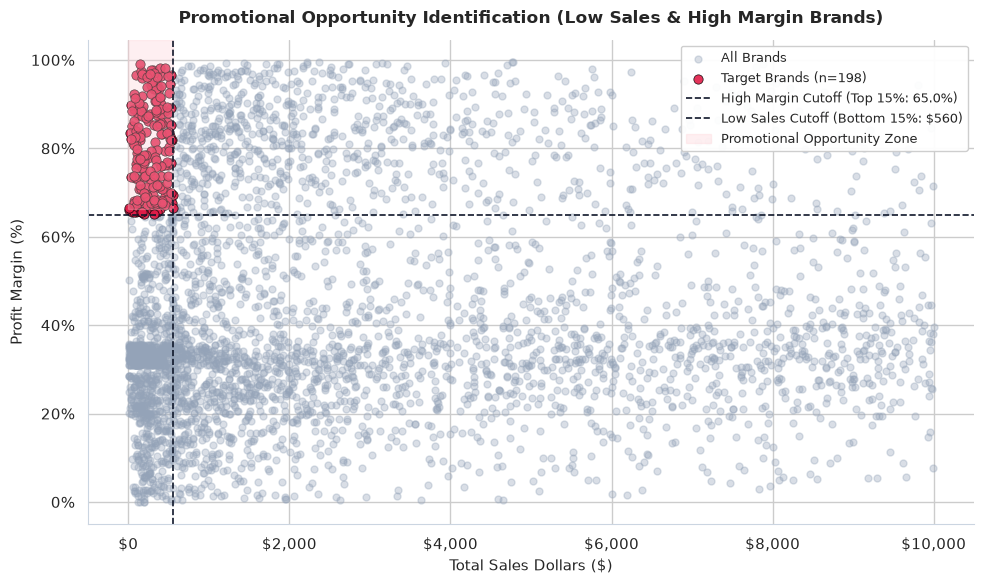

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(brand_performance['TotalSalesDollars'], brand_performance['ProfitMargin'],
            color='#94a3b8', alpha=0.35, s=25, label='All Brands')
plt.scatter(target_brands['TotalSalesDollars'], target_brands['ProfitMargin'],
            color='#e11d48', s=45, alpha=0.9, edgecolors='black', linewidth=0.5,
            label=f'Target Brands (n={len(target_brands)})')

plt.axhline(high_margin_threshold, linestyle='--', color='#0f172a', linewidth=1.2,
            label=f'High Margin Cutoff (Top 15%: {high_margin_threshold:.1f}%)')
plt.axvline(low_sales_threshold, linestyle='--', color='#0f172a', linewidth=1.2,
            label=f'Low Sales Cutoff (Bottom 15%: ${low_sales_threshold:,.0f})')

plt.axvspan(0, low_sales_threshold, ymin=(high_margin_threshold - 0) / 100, ymax=1.0,
            color='#fecdd3', alpha=0.3, label='Promotional Opportunity Zone')

plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.title("Promotional Opportunity Identification (Low Sales & High Margin Brands)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Total Sales Dollars ($)", fontsize=11, fontweight='medium')
plt.ylabel("Profit Margin (%)", fontsize=11, fontweight='medium')
plt.legend(frameon=True, facecolor='white', framealpha=0.95, loc='upper right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(IMG_DIR / "promotional_opportunity_brands.png", dpi=300, bbox_inches="tight")
plt.show()


#### Which vendors and brands demonstrate the highest sales performance?

In [17]:
def format_dollars(value):
    if abs(value) >= 1_000_000:
        return f"${value / 1_000_000:.2f}M"
    elif abs(value) >= 1_000:
        return f"${value / 1_000:.2f}K"
    else:
        return f"${value:.2f}"


In [18]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [19]:
top_vendors.apply(lambda x:format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      $67.99M
MARTIGNETTI COMPANIES         $39.33M
PERNOD RICARD USA             $32.06M
JIM BEAM BRANDS COMPANY       $31.42M
BACARDI USA INC               $24.85M
CONSTELLATION BRANDS INC      $24.22M
E & J GALLO WINERY            $18.40M
BROWN-FORMAN CORP             $18.25M
ULTRA BEVERAGE COMPANY LLP    $16.50M
M S WALKER INC                $14.71M
Name: TotalSalesDollars, dtype: str

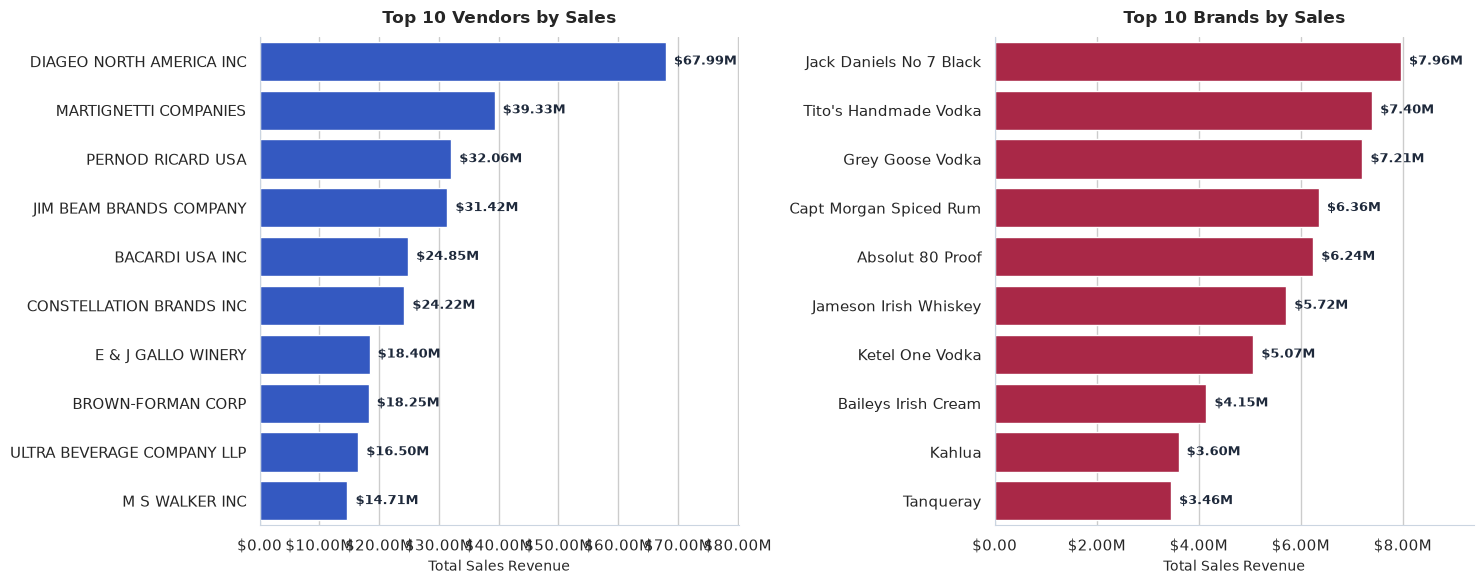

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot for Top Vendors
sns.barplot(y=top_vendors.index, x=top_vendors.values, ax=ax1, color="#1d4ed8")
ax1.set_title("Top 10 Vendors by Sales", fontsize=12, fontweight="bold", pad=10)
ax1.set_xlabel("Total Sales Revenue")
ax1.set_ylabel("")
ax1.set_xlim(0, max(top_vendors.values) * 1.18)
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format_dollars(x)))
for bar in ax1.patches:
    ax1.text(bar.get_width() + (max(top_vendors.values) * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=9, fontweight='bold', color='#1e293b')
sns.despine(ax=ax1)

# Plot for Top Brands
sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, ax=ax2, color="#be123c")
ax2.set_title("Top 10 Brands by Sales", fontsize=12, fontweight="bold", pad=10)
ax2.set_xlabel("Total Sales Revenue")
ax2.set_ylabel("")
ax2.set_xlim(0, max(top_brands.values) * 1.18)
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format_dollars(x)))
for bar in ax2.patches:
    ax2.text(bar.get_width() + (max(top_brands.values) * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=9, fontweight='bold', color='#1e293b')
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig(IMG_DIR / "top_vendors_brands_sales.png", dpi=300, bbox_inches="tight")
plt.show()


### Which vendors contribute the most to total purchase dollars?

In [21]:
# Rank Vendors by Total Purchase Dollars
vendor_performance = df.groupby("VendorName").agg({
    "TotalPurchaseDollars": "sum",
    "GrossProfit": "sum",
    "TotalSalesDollars": "sum"
}).reset_index()

# Calculate Contribution % to Overall Procurement
vendor_performance["Purchase_Contribution%"] = (vendor_performance["TotalPurchaseDollars"] / vendor_performance["TotalPurchaseDollars"].sum()) * 100

# Rank Vendors by Total Purchase Dollars & Profitability
vendor_performance = round(vendor_performance.sort_values(by="TotalPurchaseDollars", ascending=False), 2).reset_index(drop=True)

# Top 10 Vendors (preserve numeric columns for plotting, display formatted)
top_vendors = vendor_performance.head(10).copy()
display(top_vendors.assign(
    TotalSalesDollars=top_vendors['TotalSalesDollars'].apply(format_dollars),
    TotalPurchaseDollars=top_vendors['TotalPurchaseDollars'].apply(format_dollars),
    GrossProfit=top_vendors['GrossProfit'].apply(format_dollars)
))


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,Purchase_Contribution%
0,DIAGEO NORTH AMERICA INC,$50.10M,$17.89M,$67.99M,16.30
1,MARTIGNETTI COMPANIES,$25.50M,$13.83M,$39.33M,8.30
2,PERNOD RICARD USA,$23.85M,$8.21M,$32.06M,7.76
3,JIM BEAM BRANDS COMPANY,$23.49M,$7.93M,$31.42M,7.64
4,BACARDI USA INC,$17.43M,$7.42M,$24.85M,5.67
5,CONSTELLATION BRANDS INC,$15.27M,$8.95M,$24.22M,4.97
6,BROWN-FORMAN CORP,$13.24M,$5.01M,$18.25M,4.31
7,E & J GALLO WINERY,$12.07M,$6.33M,$18.40M,3.93
8,ULTRA BEVERAGE COMPANY LLP,$11.17M,$5.34M,$16.50M,3.63
9,M S WALKER INC,$9.76M,$4.94M,$14.71M,3.18


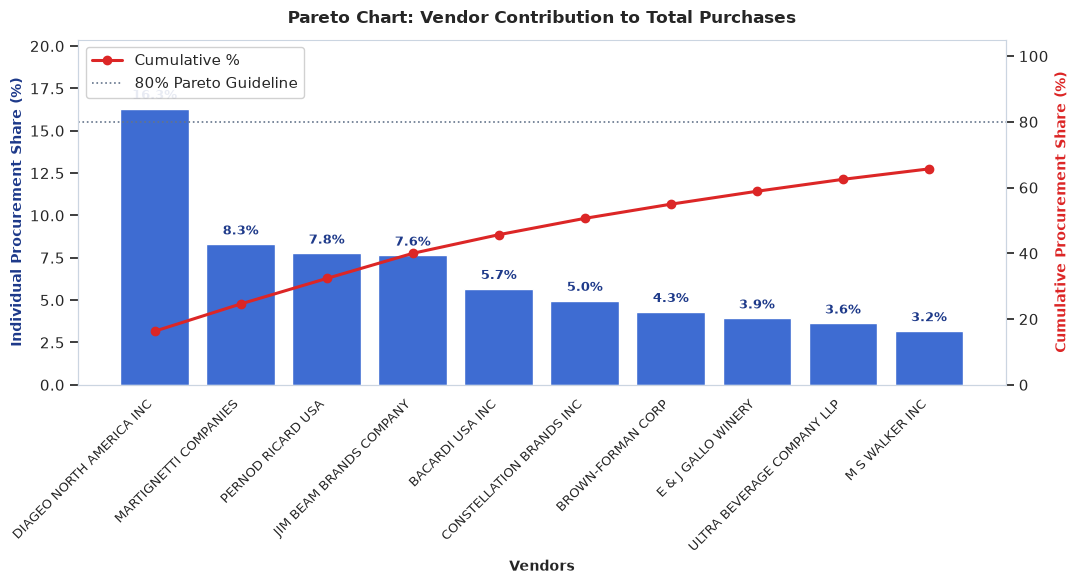

In [22]:
top_vendors['Cumulative_Contribution%'] = top_vendors['Purchase_Contribution%'].cumsum()

fig, ax1 = plt.subplots(figsize=(11, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=range(len(top_vendors)), y=top_vendors['Purchase_Contribution%'], color="#2563eb", ax=ax1, edgecolor="white")

for i, value in enumerate(top_vendors['Purchase_Contribution%']):
    ax1.text(i, value + 0.4, f"{value:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1e3a8a')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(range(len(top_vendors)), top_vendors['Cumulative_Contribution%'], color='#dc2626', marker='o', linewidth=2.2, markersize=6, label='Cumulative %')

ax1.set_xticks(range(len(top_vendors)))
ax1.set_xticklabels(top_vendors['VendorName'], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Individual Procurement Share (%)', color='#1e3a8a', fontweight='bold')
ax2.set_ylabel('Cumulative Procurement Share (%)', color='#dc2626', fontweight='bold')
ax1.set_xlabel('Vendors', fontweight='bold')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases', fontsize=12, fontweight='bold', pad=12)

ax1.set_ylim(0, max(top_vendors['Purchase_Contribution%']) * 1.25)
ax2.set_ylim(0, 105)
ax2.axhline(y=80, color='#64748b', linestyle=':', linewidth=1.2, label='80% Pareto Guideline')
ax2.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax1.grid(False)
ax2.grid(False)
sns.despine(ax=ax1, right=False)

plt.tight_layout()
plt.savefig(IMG_DIR / "vendor_procurement_pareto.png", dpi=300, bbox_inches="tight")
plt.show()


### How much of total procurement is dependent on the top vendors?

Total Purchase Contribution of top 10 vendors is 65.69 %


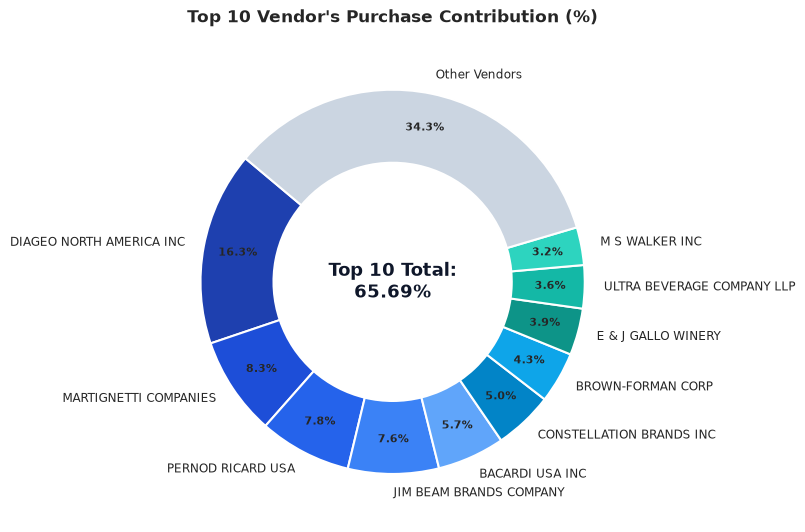

In [23]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['Purchase_Contribution%'].sum(), 2)} %")

vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['Purchase_Contribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
colors = [
    '#1e40af', '#1d4ed8', '#2563eb', '#3b82f6', '#60a5fa',
    '#0284c7', '#0ea5e9', '#0d9488', '#14b8a6', '#2dd4bf',
    '#cbd5e1'
]

wedges, texts, autotexts = ax.pie(
    purchase_contributions, labels=vendors, autopct='%1.1f%%',
    startangle=140, pctdistance=0.82, colors=colors,
    wedgeprops=dict(width=0.38, edgecolor='white', linewidth=1.5)
)

for t in texts:
    t.set_fontsize(8.5)
for at in autotexts:
    at.set_fontsize(8)
    at.set_fontweight('bold')

plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=13, fontweight='bold', ha='center', va='center', color='#0f172a')
plt.title("Top 10 Vendor's Purchase Contribution (%)", fontsize=12, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig(IMG_DIR / "top_vendors_procurement_donut.png", dpi=300, bbox_inches="tight")
plt.show()


The remaining vendors contribute only 34.31%, meaning they are not utilized effectively or may not be as competitive.
If vendor dependency is too high, consider identifying new suppliers to reduce risk.

#### Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?

In [24]:
# Calculate Unit Purchase Price per Vendor & Volume Group
df["UnitPurchasePrice"] = df["TotalPurchaseDollars"] / df["TotalPurchaseQuantity"]

# Group by Order Sizes (e.g., Small, Medium, Large Purchases)
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

# Analyze Cost Savings per Order Size
bulk_purchase_analysis = df.groupby("OrderSize")["UnitPurchasePrice"].mean().reset_index()
print(bulk_purchase_analysis)


  OrderSize  UnitPurchasePrice
0     Small          39.068186
1    Medium          15.486414
2     Large          10.777625


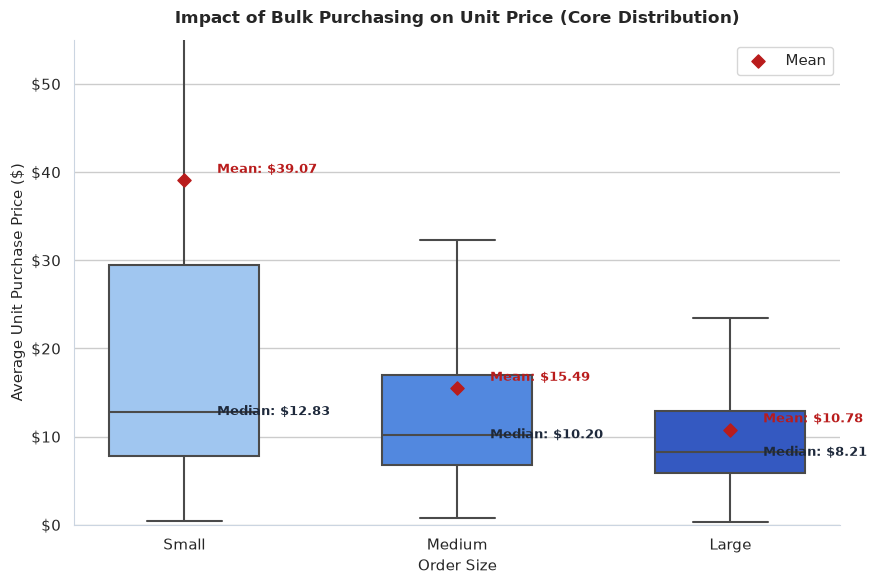

In [25]:
means = df.groupby("OrderSize", observed=False)["UnitPurchasePrice"].mean()
medians = df.groupby("OrderSize", observed=False)["UnitPurchasePrice"].median()

plt.figure(figsize=(9, 6))
palette = {"Small": "#93c5fd", "Medium": "#3b82f6", "Large": "#1d4ed8"}
ax = sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette=palette,
                 showfliers=False, width=0.55, linewidth=1.5)

for i, order in enumerate(["Small", "Medium", "Large"]):
    mean_val = means[order]
    med_val = medians[order]
    ax.scatter(i, mean_val, color='#b91c1c', marker='D', s=45, zorder=5, label='Mean' if i == 0 else "")
    ax.text(i + 0.12, med_val, f"Median: ${med_val:.2f}", va='center', fontsize=9, fontweight='bold', color='#1e293b')
    ax.text(i + 0.12, mean_val + 1.2, f"Mean: ${mean_val:.2f}", va='center', fontsize=9, fontweight='bold', color='#b91c1c')

plt.title("Impact of Bulk Purchasing on Unit Price (Core Distribution)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Order Size", fontsize=11, fontweight='medium')
plt.ylabel("Average Unit Purchase Price ($)", fontsize=11, fontweight='medium')
plt.ylim(0, 55)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.legend(frameon=True, facecolor='white', loc='upper right')
sns.despine()
plt.tight_layout()
plt.savefig(IMG_DIR / "bulk_purchasing_unit_price.png", dpi=300, bbox_inches="tight")
plt.show()


- Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
- The price difference between Small and Large orders is substantial (~72% reduction in unit cost)
- This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

#### Which vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [26]:


# Identify Low Inventory Turnover Vendors
low_turnover_vendors = df[df["StockTurnover"] < 1].groupby("VendorName")["StockTurnover"].mean().reset_index()

# Sort by Lowest Turnover
low_turnover_vendors = low_turnover_vendors.sort_values(by="StockTurnover", ascending=True)
low_turnover_vendors.head(10)


,VendorName,StockTurnover
0,ALISA CARR BEVERAGES,0.615385
36,HIGHLAND WINE MERCHANTS LLC,0.708333
60,PARK STREET IMPORTS LLC,0.751306
19,Circa Wines,0.755676
26,Dunn Wine Brokers,0.766022
15,CENTEUR IMPORTS LLC,0.773953
78,SMOKY QUARTZ DISTILLERY LLC,0.783835
90,TAMWORTH DISTILLING,0.797078
91,THE IMPORTED GRAPE LLC,0.807569
101,WALPOLE MTN VIEW WINERY,0.820548


- Slow-moving inventory increases holding costs (warehouse rent, insurance, depreciation)
- Identifying vendors with low inventory turnover is critical for business efficiency, cost reduction, and profitability


#### How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [27]:
# Calculate Unsold Inventory Value (clipping at 0 for positive capital exposure)
df["UnsoldInventoryValue"] = np.maximum(0, df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False).reset_index(drop=True)
display(inventory_value_per_vendor.head(10).assign(
    UnsoldInventoryValue=inventory_value_per_vendor.head(10)['UnsoldInventoryValue'].apply(format_dollars)
))


Total Unsold Capital: $9.55M


,VendorName,UnsoldInventoryValue
0,DIAGEO NORTH AMERICA INC,$1.40M
1,MARTIGNETTI COMPANIES,$882.51K
2,JIM BEAM BRANDS COMPANY,$833.26K
3,PERNOD RICARD USA,$638.98K
4,ULTRA BEVERAGE COMPANY LLP,$506.53K
5,WILLIAM GRANT & SONS INC,$468.09K
6,E & J GALLO WINERY,$399.97K
7,CONSTELLATION BRANDS INC,$346.40K
8,PERFECTA WINES,$344.63K
9,BROWN-FORMAN CORP,$337.28K


#### What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


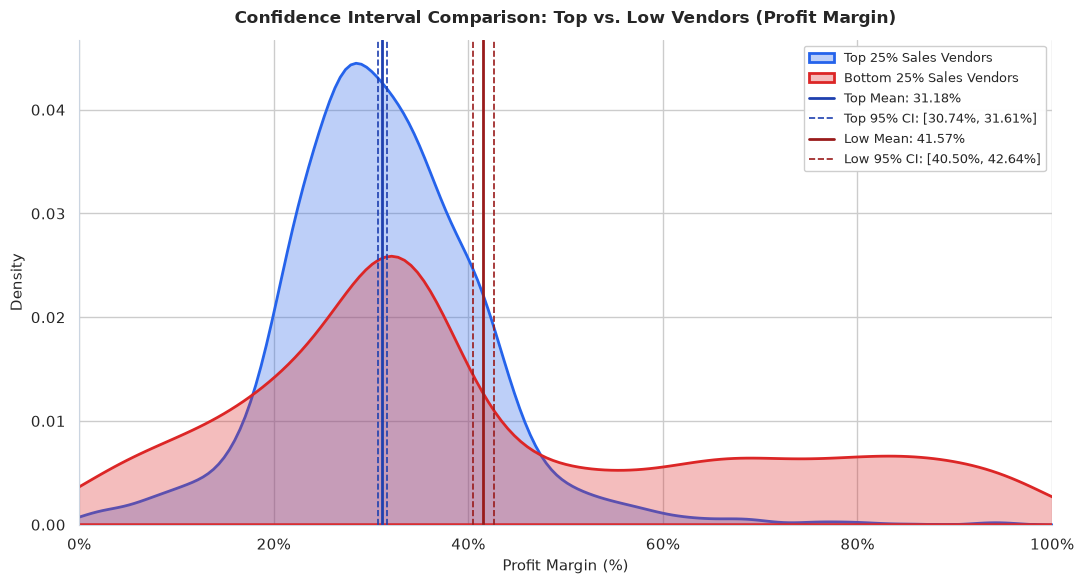

In [28]:
# Define top and low vendors based on Total Sales Dollars (Top 25% & Bottom 25%)
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Function to compute confidence interval
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = stats.sem(data)  # Standard error
    margin_of_error = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1) * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

# Compute confidence intervals
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(11, 6))

# Density plots
sns.kdeplot(top_vendors, color="#2563eb", fill=True, alpha=0.3, linewidth=2, label="Top 25% Sales Vendors")
sns.kdeplot(low_vendors, color="#dc2626", fill=True, alpha=0.3, linewidth=2, label="Bottom 25% Sales Vendors")

# Top Vendors lines
plt.axvline(top_mean, color="#1e40af", linestyle="-", linewidth=2, label=f"Top Mean: {top_mean:.2f}%")
plt.axvline(top_lower, color="#1e40af", linestyle="--", linewidth=1.2, label=f"Top 95% CI: [{top_lower:.2f}%, {top_upper:.2f}%]")
plt.axvline(top_upper, color="#1e40af", linestyle="--", linewidth=1.2)

# Low Vendors lines
plt.axvline(low_mean, color="#991b1b", linestyle="-", linewidth=2, label=f"Low Mean: {low_mean:.2f}%")
plt.axvline(low_lower, color="#991b1b", linestyle="--", linewidth=1.2, label=f"Low 95% CI: [{low_lower:.2f}%, {low_upper:.2f}%]")
plt.axvline(low_upper, color="#991b1b", linestyle="--", linewidth=1.2)

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Profit Margin (%)", fontsize=11, fontweight='medium')
plt.ylabel("Density", fontsize=11, fontweight='medium')
plt.xlim(0, 100)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend(frameon=True, facecolor='white', framealpha=0.95, loc='upper right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(IMG_DIR / "profit_margin_confidence_intervals.png", dpi=300, bbox_inches="tight")
plt.show()


- The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
- For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
- For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

#### Is there a significant difference in profit margins between top-performing and low-performing vendors?

Hypothesis:

H₀ (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H₁ (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [29]:

top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")


T-Statistic: -17.6695, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.


- A p-value this small suggests that the difference is not just statistically significant but also practically meaningful.

- The two vendor groups operate very differently in terms of profitability.

---

## 🏁 Strategic Recommendations & Action Plan

1. **Promotional Targeting:** Launch pilot campaigns on identified low-sales, high-margin brands where margin headroom allows price stimulation without eroding overall profitability.
2. **Supplier Diversification:** Implement multi-sourcing and SLA negotiations for the top-10 vendors accounting for ~65.7% of total procurement spend to mitigate supplier dependency risk.
3. **Bulk Procurement Optimization:** Consolidate purchase orders into large order tiers to capture the ~72% unit cost reduction ($10.78 vs $39.07), while establishing minimum reorder triggers to prevent stock holding creep.
4. **Inventory Rationalization:** Conduct review meetings with low-turnover vendors (< 1.0) and liquidate slow-moving SKUs to unlock capital tied in unsold inventory.
5. **Tier-Specific Commercial Strategies:** Maintain differentiated margin and volume targets, recognizing that high-sales volume vendors operate on tighter, high-velocity margins while smaller vendors command higher margins.

> **Note:** Raw CSV ingestion into the SQLite database is managed separately via `scripts/ingest.py`.
